# Vietnamese Speech Emotion Recognition (SER) - Academic Companion Notebook

This notebook serves as the **academic artifact generator** and **live demonstration** for the SER thesis. It:
1. Performs deep Exploratory Data Analysis (EDA) on ViSEC with quantitative metrics.
2. Generates publication-quality figures for the LaTeX report.
3. Visualizes benchmark results, confusion matrices, and error patterns.
4. Runs live inference demonstrations.

**Prerequisites:** Run `generate_splits.py` and train models first.


In [1]:
# ==================== 1. SETUP & LOAD ARTIFACTS ====================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import librosa
import warnings
from pathlib import Path
from scipy.stats import entropy as sp_entropy

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 10})

if os.getcwd().endswith('internal'):
    os.chdir('..')

import sys
sys.path.append(os.path.abspath('.'))
from src.config.paths import BENCHMARK_RESULTS_PATH, ROOT_DIR

print("Loading Benchmark Results...")
if BENCHMARK_RESULTS_PATH.exists():
    with open(BENCHMARK_RESULTS_PATH, 'r', encoding='utf-8') as f:
        benchmark_data = json.load(f)
    emotion_labels = benchmark_data['emotion_labels']
    print(f"\u2713 Loaded benchmark results for {len(benchmark_data['ranked_results'])} models.")
else:
    print("benchmark_results_gpu.json not found. Run benchmark_methods_gpu.py first.")
    emotion_labels = ['angry', 'happy', 'neutral', 'sad']

from typing import Any

def run_script(script: Path, args: list[str]) -> tuple[int, str, str]:
    import subprocess
    cmd = [sys.executable, str(script), *args]
    proc = subprocess.run(cmd, cwd=str(script.parent), capture_output=True, text=True)
    return proc.returncode, proc.stdout.strip(), proc.stderr.strip()

def extract_json_object(text: str) -> Any | None:
    import re
    text = text.strip()
    if not text:
        return None
    try:
        return json.loads(text)
    except Exception:
        pass
    candidates = re.findall(r"\{.*\}", text, flags=re.DOTALL)
    for candidate in reversed(candidates):
        try:
            return json.loads(candidate)
        except Exception:
            continue
    return None

IMG_DIR = Path("report_images")
IMG_DIR.mkdir(exist_ok=True)


Loading Benchmark Results...
✓ Loaded benchmark results for 3 models.


## Exploratory Data Analysis



Loading dataset for EDA...


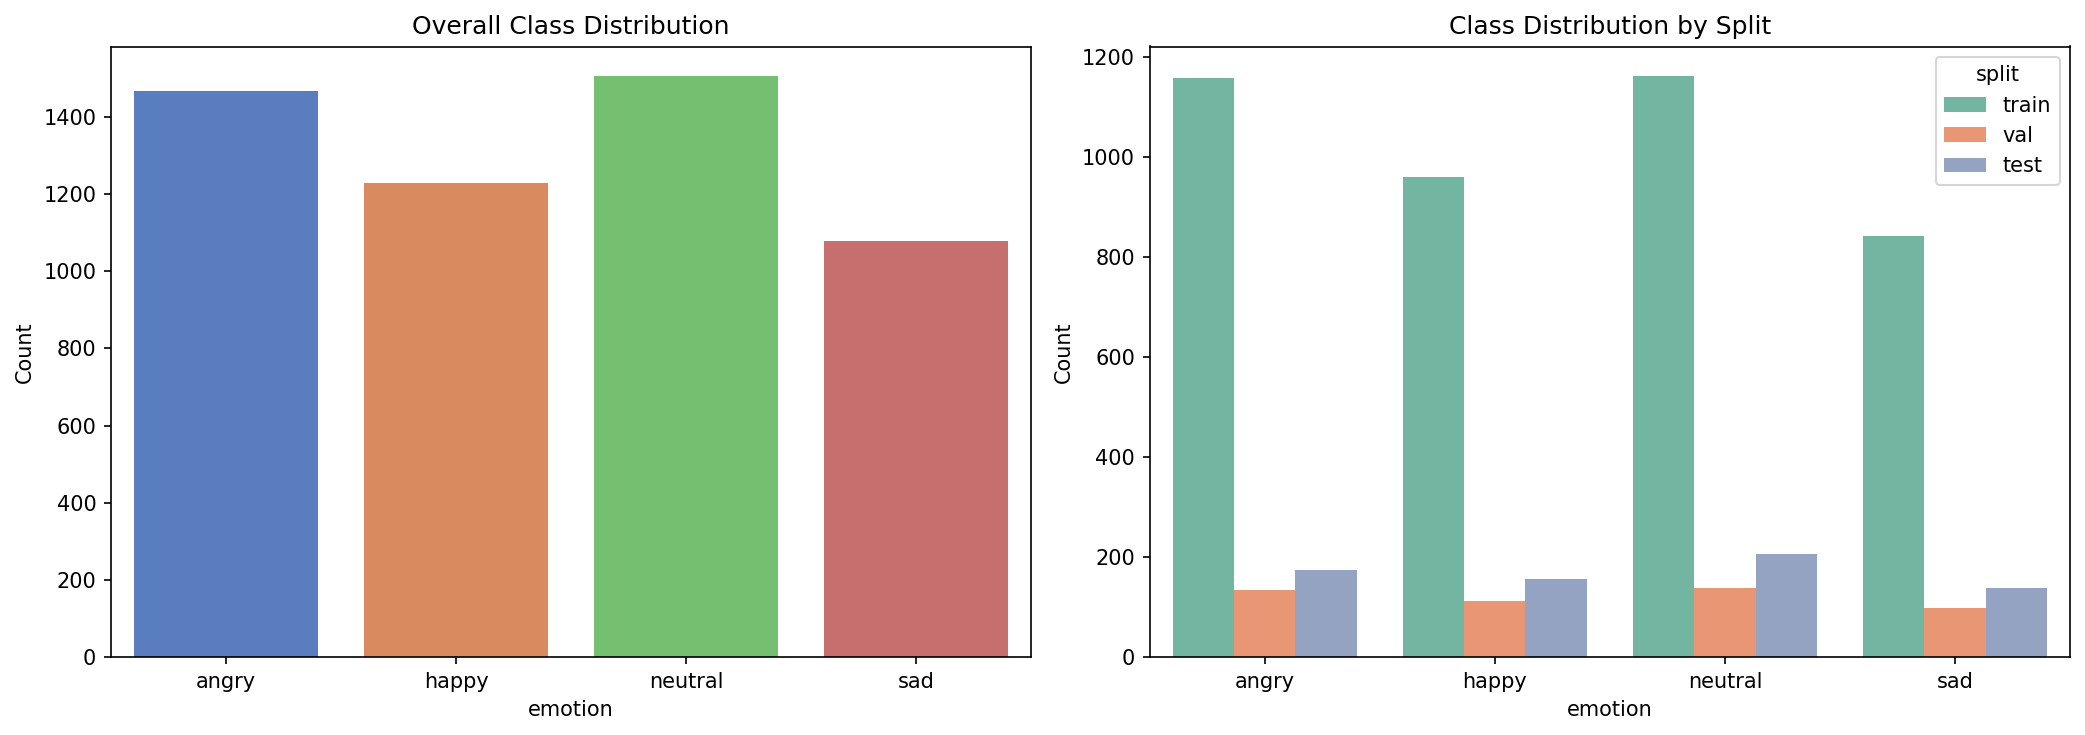

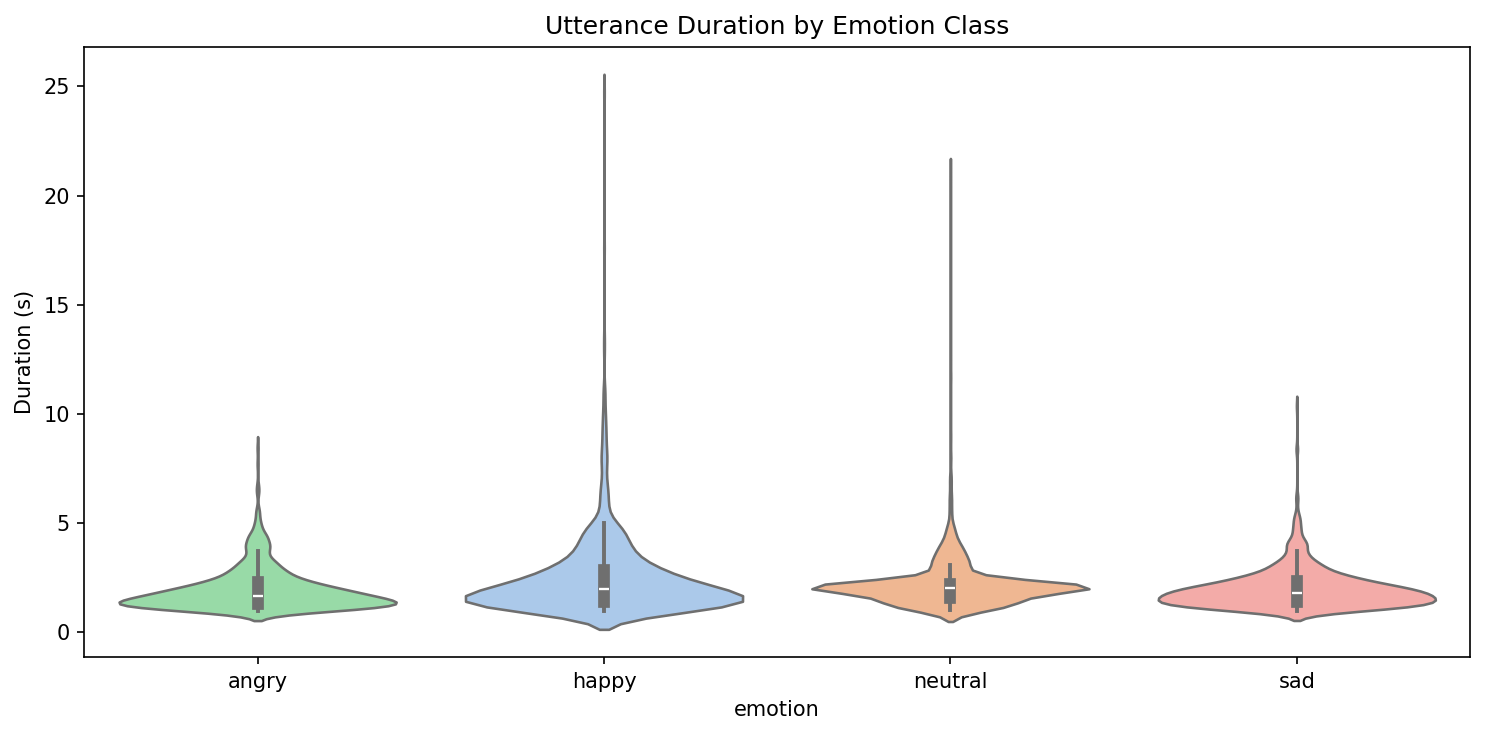

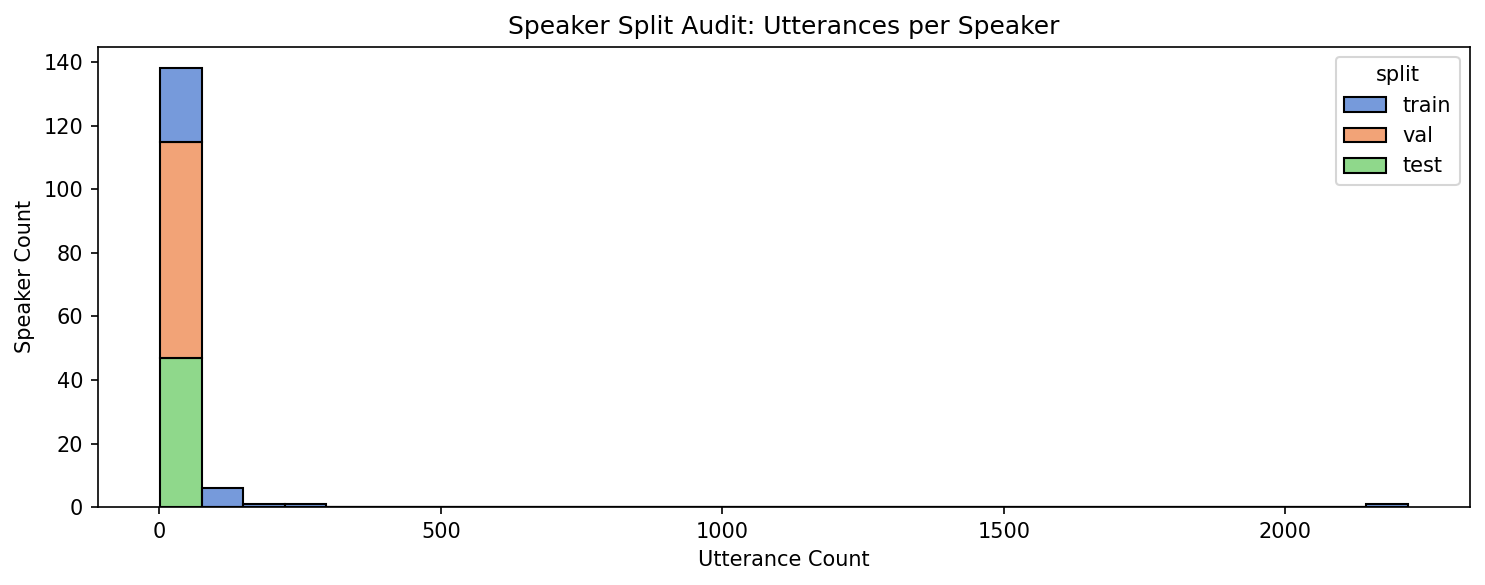

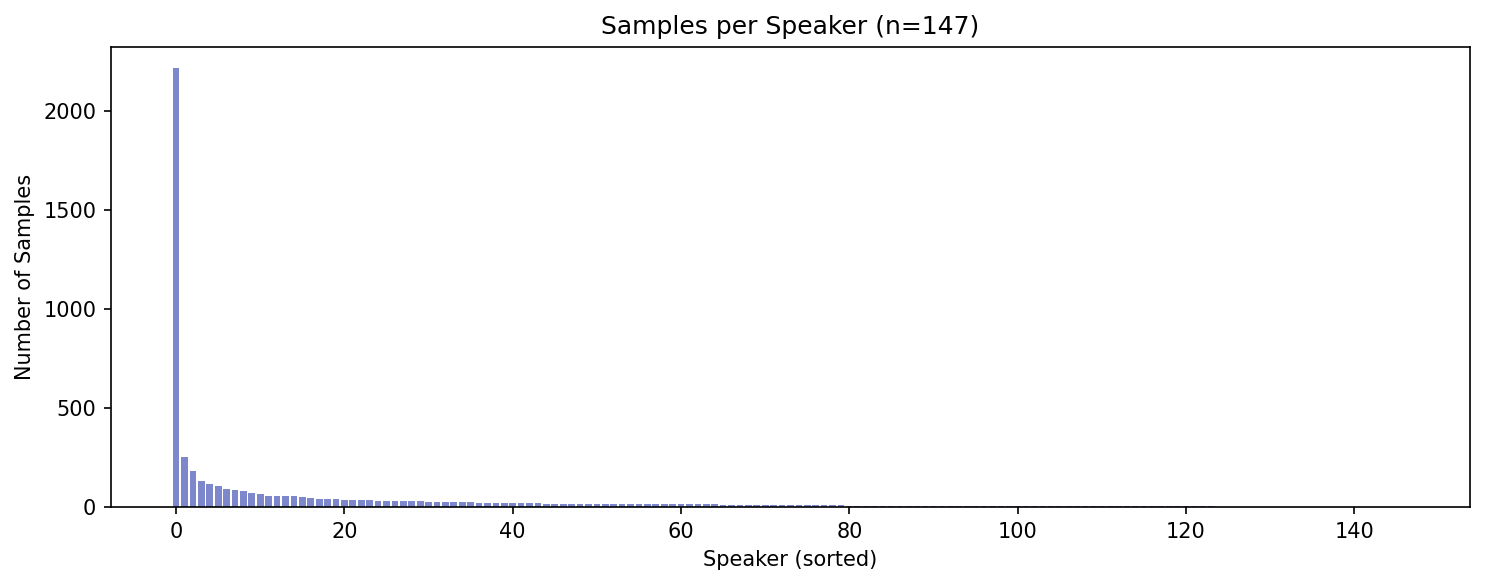


QUANTITATIVE DATASET METRICS
Total samples: 5280
Classes: ['neutral', 'angry', 'happy', 'sad']
Counts: {'neutral': 1507, 'angry': 1466, 'happy': 1228, 'sad': 1079}
Shannon Entropy: 1.9871 bits (max = 2.0000)
Balance Ratio (H/H_max): 0.9935 (1.0 = perfect)
Imbalance Ratio (max/min): 1.40
Mean duration: 2.17s (std=1.25s)
Median duration: 1.94s
90th percentile: 3.58s
95th percentile: 4.42s

[TRAIN] n=4120, speakers=32, entropy=1.9872, balance=0.9936

[VAL] n=484, speakers=68, entropy=1.9868, balance=0.9934

[TEST] n=676, speakers=47, entropy=1.9843, balance=0.9921


In [2]:
# ==================== 1.5. EXPLORATORY DATA ANALYSIS (EDA) ====================
from datasets import load_dataset
from scipy.stats import entropy as sp_entropy

print("Loading dataset for EDA...")
dataset = load_dataset("hustep-lab/ViSEC", split="train", trust_remote_code=True)
df = dataset.to_pandas()

manifest_path = ROOT_DIR / "split_manifest.json"
if manifest_path.exists():
    with open(manifest_path, "r") as f:
        manifest = json.load(f)
    train_idx = manifest["train_indices"]
    val_idx = manifest["val_indices"]
    test_idx = manifest["test_indices"]
    df['split'] = 'none'
    df.loc[train_idx, 'split'] = 'train'
    df.loc[val_idx, 'split'] = 'val'
    df.loc[test_idx, 'split'] = 'test'
else:
    df['split'] = 'train'

# ── 1. Class Distribution (overall + per-split)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['angry', 'happy', 'neutral', 'sad']
sns.countplot(data=df, x='emotion', order=order, palette='muted', ax=axes[0])
axes[0].set_title("Overall Class Distribution")
axes[0].set_ylabel("Count")
sns.countplot(data=df, x='emotion', hue='split', order=order, palette='Set2', ax=axes[1])
axes[1].set_title("Class Distribution by Split")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig(IMG_DIR / "class_distribution.png", bbox_inches='tight')
plt.show()

# ── 2. Duration Violin
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x='emotion', y='duration', hue='emotion',
               palette='pastel', order=order, legend=False, ax=ax)
ax.set_title("Utterance Duration by Emotion Class")
ax.set_ylabel("Duration (s)")
plt.tight_layout()
plt.savefig(IMG_DIR / "duration_violin.png", bbox_inches='tight')
plt.show()

# ── 3. Speaker Split Audit
speaker_counts = df.groupby(['speaker_id', 'split']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=speaker_counts, x='count', hue='split', multiple='stack',
             bins=30, palette='muted', ax=ax)
ax.set_title("Speaker Split Audit: Utterances per Speaker")
ax.set_xlabel("Utterance Count")
ax.set_ylabel("Speaker Count")
plt.tight_layout()
plt.savefig(IMG_DIR / "speaker_histogram.png", bbox_inches='tight')
plt.show()

# ── 4. Samples per Speaker
spk_total = df.groupby('speaker_id').size().reset_index(name='n_samples')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(spk_total)), sorted(spk_total['n_samples'], reverse=True),
       color='#5C6BC0', alpha=0.8)
ax.set_xlabel("Speaker (sorted)")
ax.set_ylabel("Number of Samples")
ax.set_title(f"Samples per Speaker (n={len(spk_total)})")
plt.tight_layout()
plt.savefig(IMG_DIR / "samples_per_speaker.png", bbox_inches='tight')
plt.show()

# ── 5. Quantitative Dataset Metrics
print("\n" + "="*60)
print("QUANTITATIVE DATASET METRICS")
print("="*60)
total = len(df)
class_counts = df['emotion'].value_counts()
proportions = class_counts / total
H = sp_entropy(proportions, base=2)
H_max = np.log2(len(class_counts))
balance_ratio = H / H_max
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Total samples: {total}")
print(f"Classes: {list(class_counts.index)}")
print(f"Counts: {dict(class_counts)}")
print(f"Shannon Entropy: {H:.4f} bits (max = {H_max:.4f})")
print(f"Balance Ratio (H/H_max): {balance_ratio:.4f} (1.0 = perfect)")
print(f"Imbalance Ratio (max/min): {imbalance_ratio:.2f}")
print(f"Mean duration: {df['duration'].mean():.2f}s (std={df['duration'].std():.2f}s)")
print(f"Median duration: {df['duration'].median():.2f}s")
print(f"90th percentile: {df['duration'].quantile(0.9):.2f}s")
print(f"95th percentile: {df['duration'].quantile(0.95):.2f}s")

for split_name in ['train', 'val', 'test']:
    sub = df[df['split'] == split_name]
    sc = sub['emotion'].value_counts()
    sp = sc / len(sub)
    sh = sp_entropy(sp, base=2)
    print(f"\n[{split_name.upper()}] n={len(sub)}, "
          f"speakers={sub['speaker_id'].nunique()}, "
          f"entropy={sh:.4f}, "
          f"balance={sh/H_max:.4f}")


## Results Summary




--- Confusion Matrices ---


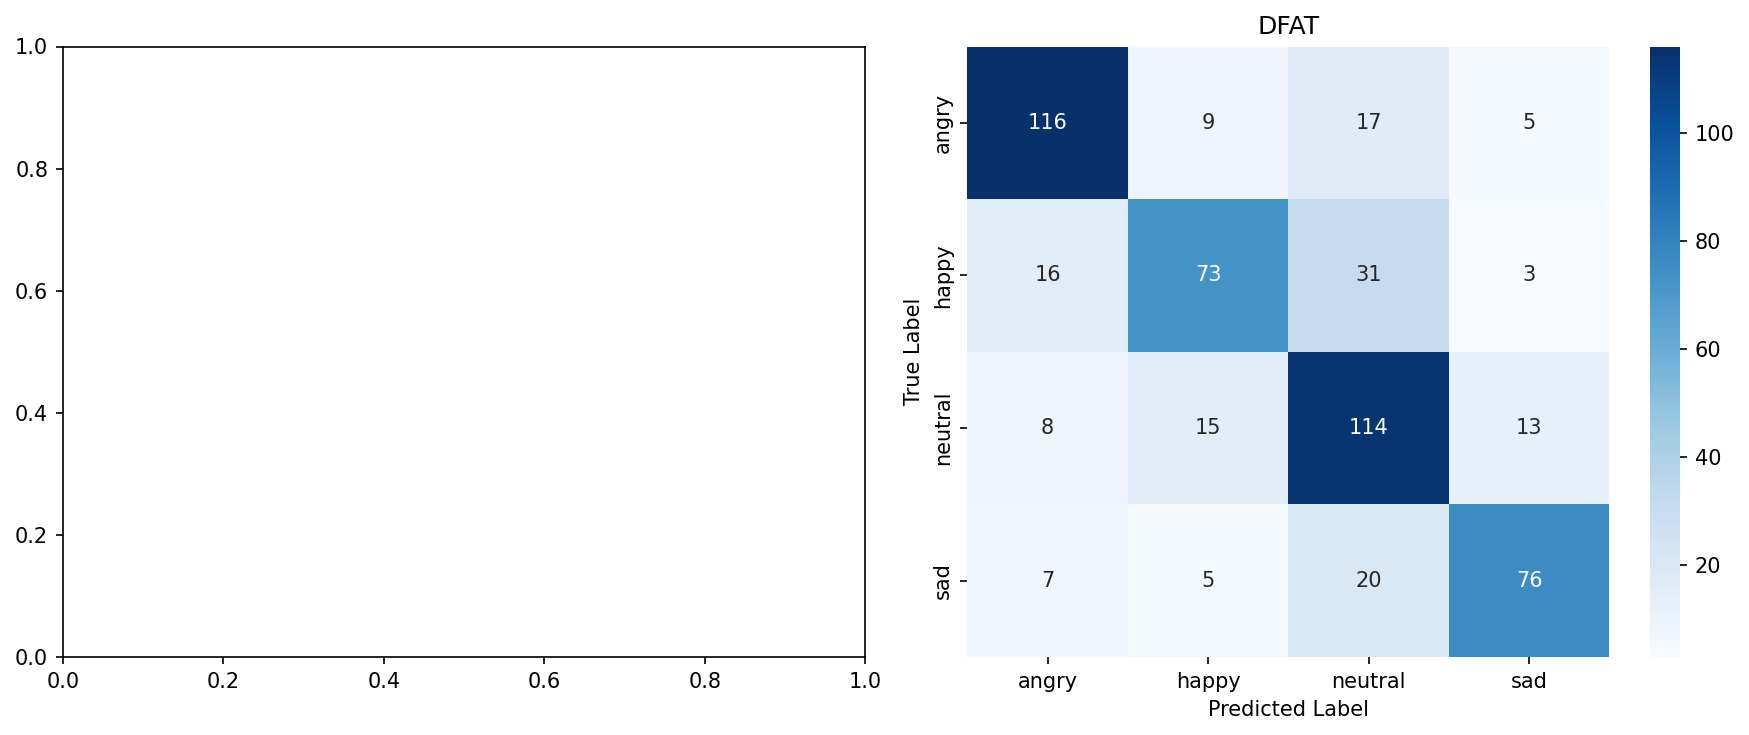

In [3]:
# ==================== 2. CONFUSION MATRICES ====================
if BENCHMARK_RESULTS_PATH.exists():
    print("\n--- Confusion Matrices ---")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, (ax, model_name) in enumerate(zip(axes, ["ECAPA-TDNN (simplified implementation)", "DFAT Late Fusion"])):
        model_res = next((r for r in benchmark_data['ranked_results'] if r['method'] == model_name), None)
        if model_res and 'confusion_matrix' in model_res['representative_run']:
            cm = np.array(model_res['representative_run']['confusion_matrix'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax)
            short = "ECAPA" if "ECAPA" in model_name else "DFAT"
            ax.set_title(short)
            ax.set_ylabel('True Label')
            ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(IMG_DIR / "confusion_matrices_side.png", bbox_inches='tight')
    plt.show()


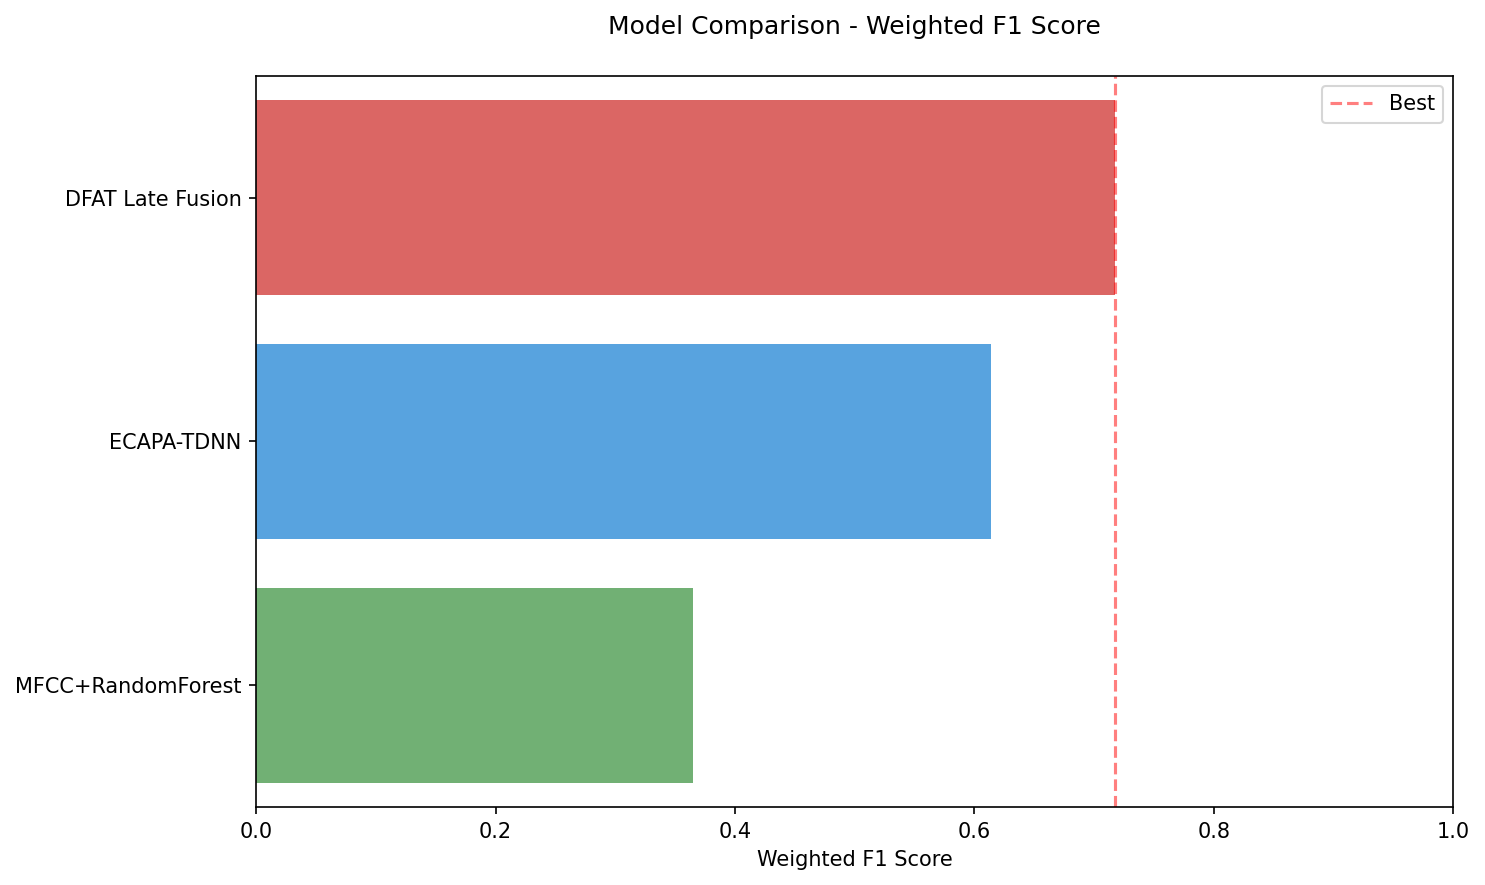

In [4]:
# ==================== 3. MODEL COMPARISON CHART ====================
benchmark_path = ROOT_DIR / "benchmark_results_gpu.json"
if benchmark_path.exists():
    with open(benchmark_path, 'r') as f:
        data = json.load(f)
    
    methods = []
    wf1s = []
    for r in data.get("ranked_results", []):
        methods.append(r["method"])
        wf1s.append(r.get("f1_weighted_mean", 0))
        
    plt.figure(figsize=(10, 6))
    colors = ['#EF5350', '#42A5F5', '#66BB6A'][:len(methods)]
    sns.barplot(x=wf1s, y=methods, palette=colors)
    plt.title("Model Comparison - Weighted F1 Score", pad=20)
    plt.xlabel("Weighted F1 Score")
    plt.xlim(0, 1.0)
    best_wf1 = max(wf1s) if wf1s else 0
    plt.axvline(x=best_wf1, color='red', linestyle='--', alpha=0.5, label='Best')
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMG_DIR / "model_comparison.png", bbox_inches='tight')
    plt.show()
else:
    print("benchmark_results_gpu.json not found.")


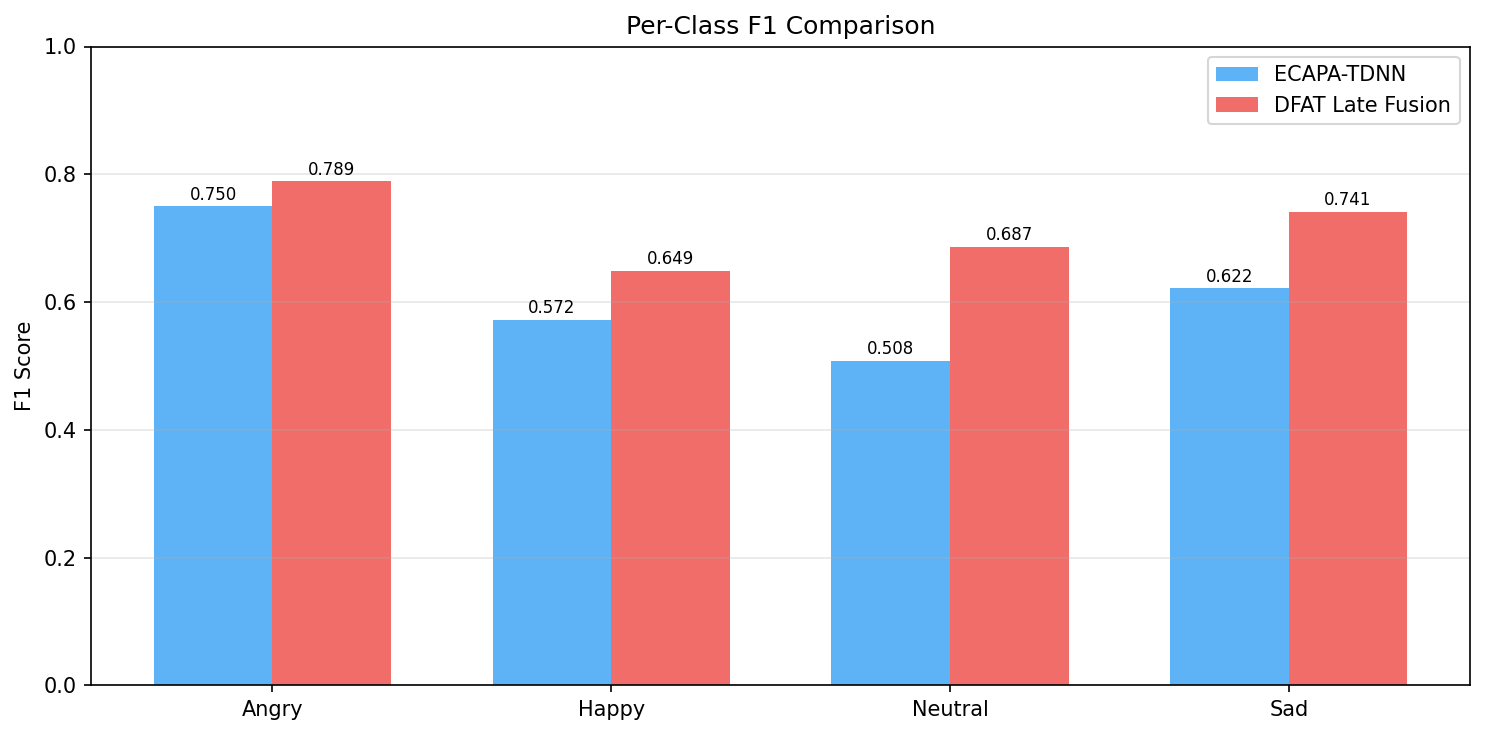

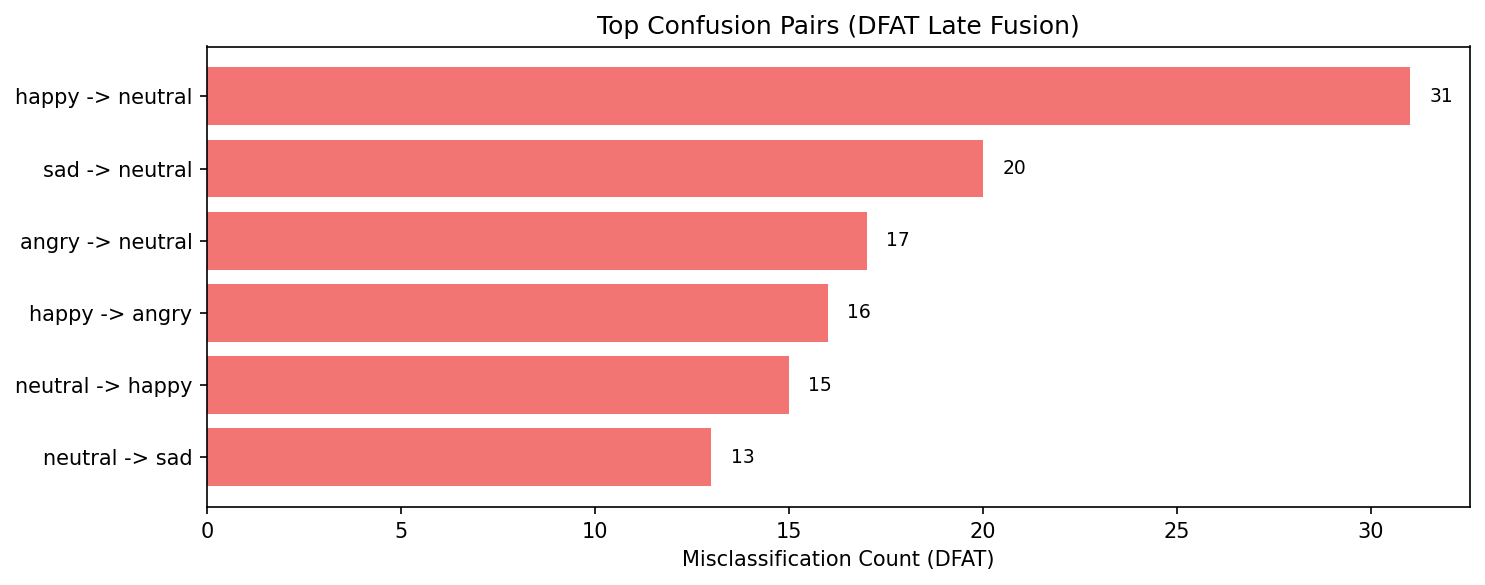

In [5]:
# ==================== 3.5 PER-CLASS F1 & TOP CONFUSION PAIRS ====================
if BENCHMARK_RESULTS_PATH.exists():
    # Per-class F1
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(emotion_labels))
    width = 0.35
    
    ecapa_res = next((r for r in benchmark_data['ranked_results'] if 'ECAPA' in r['method']), None)
    dfat_res = next((r for r in benchmark_data['ranked_results'] if 'DFAT' in r['method']), None)
    
    if ecapa_res and dfat_res:
        ecapa_f1 = [ecapa_res['representative_run']['classification_report'][e]['f1-score'] for e in emotion_labels]
        dfat_f1 = [dfat_res['representative_run']['classification_report'][e]['f1-score'] for e in emotion_labels]
        ax.bar(x - width/2, ecapa_f1, width, label='ECAPA-TDNN', color='#42A5F5', alpha=0.85)
        ax.bar(x + width/2, dfat_f1, width, label='DFAT Late Fusion', color='#EF5350', alpha=0.85)
        for i in range(len(emotion_labels)):
            ax.text(x[i] - width/2, ecapa_f1[i] + 0.01, f'{ecapa_f1[i]:.3f}', ha='center', fontsize=8)
            ax.text(x[i] + width/2, dfat_f1[i] + 0.01, f'{dfat_f1[i]:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([e.capitalize() for e in emotion_labels])
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1)
    ax.set_title("Per-Class F1 Comparison")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMG_DIR / "per_class_f1.png", bbox_inches='tight')
    plt.show()
    
    # Top confusion pairs
    if dfat_res:
        cm = np.array(dfat_res['representative_run']['confusion_matrix'])
        pairs = []
        for i in range(len(emotion_labels)):
            for j in range(len(emotion_labels)):
                if i != j:
                    pairs.append((emotion_labels[i], emotion_labels[j], cm[i][j]))
        pairs.sort(key=lambda x: x[2], reverse=True)
        
        top = pairs[:6]
        labels_pair = [f"{a} -> {b}" for a, b, _ in top]
        counts = [c for _, _, c in top]
        
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.barh(labels_pair[::-1], counts[::-1], color='#EF5350', alpha=0.8)
        ax.set_xlabel("Misclassification Count (DFAT)")
        ax.set_title("Top Confusion Pairs (DFAT Late Fusion)")
        for i, v in enumerate(counts[::-1]):
            ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
        plt.tight_layout()
        plt.savefig(IMG_DIR / "top_confusion_pairs.png", bbox_inches='tight')
        plt.show()


In [6]:
# ==================== 4. ABLATION STUDY RESULTS ====================
ablation_path = ROOT_DIR / "DFAT_Hybrid_Fusion" / "ablation_results.json"
if ablation_path.exists():
    with open(ablation_path, 'r') as f:
        data = json.load(f)
        
    records = []
    for r in data.get("ablation_results", []):
        ens = r.get("ensemble", {})
        records.append({
            "Configuration": r["config"],
            "Weighted F1": ens.get("f1_weighted", 0),
            "Macro F1": ens.get("f1_macro", 0),
            "Accuracy": ens.get("accuracy", 0)
        })
        
    df_ablation = pd.DataFrame(records)
    from IPython.display import display
    display(df_ablation.style.background_gradient(cmap='Blues', subset=['Weighted F1']))
else:
    print("Ablation results not found. Run ablation_study.py first.")


,Configuration,Weighted F1,Macro F1,Accuracy
0,Acoustic-only (WavLM),0.432900,0.427800,0.435600
1,Linguistic-only (Whisper-small + PhoBERT),0.336400,0.334900,0.344700
2,Early Fusion (Concat 1536-d),0.399500,0.393700,0.399600
3,Late Fusion (stream-level),0.340800,0.338300,0.365500
4,Linguistic-only (Whisper-tiny + PhoBERT),0.262400,0.251200,0.270800
5,Early Fusion (Whisper-tiny),0.404400,0.397200,0.407200
6,Early Fusion + 10% synthetic noise,0.428000,0.421600,0.429900
7,Early Fusion + 20% synthetic noise,0.424200,0.417900,0.428000
8,Early Fusion + 30% synthetic noise,0.416500,0.416900,0.416700


## Qualitative Analysis & Case Studies



In [7]:
# ==================== 4.5 QUALITATIVE CASE STUDIES ====================
# Extract per-sample predictions from benchmark confusion data
if BENCHMARK_RESULTS_PATH.exists():
    dfat_res = next((r for r in benchmark_data['ranked_results'] if 'DFAT' in r['method']), None)
    ecapa_res = next((r for r in benchmark_data['ranked_results'] if 'ECAPA' in r['method']), None)
    
    if dfat_res:
        cm = np.array(dfat_res['representative_run']['confusion_matrix'])
        report = dfat_res['representative_run']['classification_report']
        
        print("="*70)
        print("QUALITATIVE CASE STUDY SUMMARY (DFAT Late Fusion)")
        print("="*70)
        
        # Best and worst classes
        class_f1 = {e: report[e]['f1-score'] for e in emotion_labels}
        best_class = max(class_f1, key=class_f1.get)
        worst_class = min(class_f1, key=class_f1.get)
        
        print(f"\nBest recognized class:  {best_class.upper()} (F1={class_f1[best_class]:.3f})")
        print(f"Worst recognized class: {worst_class.upper()} (F1={class_f1[worst_class]:.3f})")
        
        # Dominant confusion pairs
        print("\nTop confusion pairs (true -> predicted, count):")
        pairs = []
        for i in range(len(emotion_labels)):
            for j in range(len(emotion_labels)):
                if i != j and cm[i][j] > 0:
                    pairs.append((emotion_labels[i], emotion_labels[j], cm[i][j]))
        pairs.sort(key=lambda x: x[2], reverse=True)
        for true_e, pred_e, count in pairs[:5]:
            pct = count / cm[emotion_labels.index(true_e)].sum() * 100
            print(f"  {true_e:>8} -> {pred_e:<8}: {count:3d} samples ({pct:.1f}% of true {true_e})")
        
        # Failure mode categorization
        print("\n--- Failure Mode Categorization ---")
        acoustic_ambiguity = sum(c for t, p, c in pairs if 
            (t in ['happy','sad'] and p == 'neutral') or (t == 'neutral' and p in ['happy','sad']))
        asr_noise = sum(c for t, p, c in pairs if t == 'angry' and p != 'angry')
        other = sum(c for _, _, c in pairs) - acoustic_ambiguity - asr_noise
        total_errors = sum(c for _, _, c in pairs)
        
        print(f"  Acoustic Ambiguity (Happy/Sad <-> Neutral): {acoustic_ambiguity} ({acoustic_ambiguity/total_errors*100:.1f}%)")
        print(f"  ASR Noise (Angry misclassified): {asr_noise} ({asr_noise/total_errors*100:.1f}%)")
        print(f"  Other cross-class errors: {other} ({other/total_errors*100:.1f}%)")
        print(f"  Total off-diagonal errors: {total_errors}")


QUALITATIVE CASE STUDY SUMMARY (DFAT Late Fusion)

Best recognized class:  ANGRY (F1=0.789)
Worst recognized class: HAPPY (F1=0.649)

Top confusion pairs (true -> predicted, count):
     happy -> neutral :  31 samples (25.2% of true happy)
       sad -> neutral :  20 samples (18.5% of true sad)
     angry -> neutral :  17 samples (11.6% of true angry)
     happy -> angry   :  16 samples (13.0% of true happy)
   neutral -> happy   :  15 samples (10.0% of true neutral)

--- Failure Mode Categorization ---
  Acoustic Ambiguity (Happy/Sad <-> Neutral): 79 (53.0%)
  ASR Noise (Angry misclassified): 31 (20.8%)
  Other cross-class errors: 39 (26.2%)
  Total off-diagonal errors: 149


In [8]:
# ==================== 5. LIVE INFERENCE DEMO ====================
demo_audio = ROOT_DIR / "sample_visec.wav"

def try_predict_ecapa(audio_path: Path) -> Any | None:
    script = ROOT_DIR / "ECAPA" / "predict_emotion.py"
    model_dir = ROOT_DIR / "ECAPA" / "emotion_model"
    if not script.exists():
        print("ECAPA predict script not found.")
        return None
    rc, out, err = run_script(script, [str(audio_path), "--model_dir", str(model_dir)])
    if rc != 0:
        print("ECAPA script failed:")
        print(err or out)
        return None
    parsed = extract_json_object(out)
    print("ECAPA raw output:")
    print(out)
    return parsed if parsed is not None else out

def try_predict_dfat(audio_path: Path) -> Any | None:
    script = ROOT_DIR / "DFAT_Hybrid_Fusion" / "predict_dualstream.py"
    model_dir = ROOT_DIR / "DFAT_Hybrid_Fusion" / "dualstream_model"
    if not script.exists():
        print("DFAT predict script not found.")
        return None
    rc, out, err = run_script(script, ["--audio_file", str(audio_path), "--model_dir", str(model_dir)])
    if rc != 0:
        print("DFAT script failed:")
        print(err or out)
        return None
    parsed = extract_json_object(out)
    print("DFAT raw output:")
    print(out)
    return parsed if parsed is not None else out

if demo_audio.exists():
    print(f"Sample audio: {demo_audio}")
    import IPython.display as ipd
    from IPython.display import display
    display(ipd.Audio(str(demo_audio)))
    
    print("\n--- Running ECAPA-TDNN Inference ---")
    ecapa_pred = try_predict_ecapa(demo_audio)
    
    print("\n--- Running DFAT Late Fusion Inference ---")
    dfat_pred = try_predict_dfat(demo_audio)
else:
    print("sample_visec.wav is missing; skip demo inference.")


Sample audio: /mnt/12bc61a2-ddc5-4be8-b8be-bbd99dc6d141/AI engineer/Study/Speech-Emotions-Recognition/sample_visec.wav



--- Running ECAPA-TDNN Inference ---


ECAPA raw output:
{"angry": 9.920432830767822e-07, "happy": 0.9994409680366516, "neutral": 0.00016454940487165004, "sad": 0.0003935198183171451}

--- Running DFAT Late Fusion Inference ---


DFAT script failed:
Some weights of the model checkpoint at microsoft/wavlm-base-plus were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at microsoft/wavlm-base-plus and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to 